- 1.load the dataset into a Pandas DataFrame — use pd.read_csv() or pd.read_sql()
- 2 Print df.shape, df.info(), df.dtypes — document what you find in comments
- 3 Check for missing values: df.isnull().sum() — what % is missing per column?
- 4 Run df.describe() — identify 3 observations (e.g. mean vs median, suspicious min/max)
- 5 Run df['col'].value_counts() on at least 1 categorical column
- 6 Plot a histogram for every numeric column — do they look normal or skewed?
- 7 Plot a box plot for at least 2 columns — are there outliers?
- 8 Write a 5-line comment block at the top summarising what you found
- Deliverable: .py script with all 8 steps + charts saved as
- .png files
- Bonus: Use sns.pairplot() on all numeric columns and
- describe what you see


In [3]:
!pip install pandas matplotlib seaborn numpy

  Using cached pandas-3.0.3-cp314-cp314-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.3-cp314-cp314-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
Using cached matplotlib-3.10.9-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 1.2 MB/s  0:00:13 eta 0:00:010:00:01m
Using cached contourpy-1.3.3-cp314-cp31

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set default plot style
sns.set_style("whitegrid")

## Data Loading and Initial Inspection

In [20]:
# 1. Load the dataset into a Pandas DataFrame
file_path = '../../day_3/articles.csv'
df = pd.read_csv(file_path)

# 2. Print df.shape, df.info(), df.dtypes
print(f"Dataset shape: {df.shape}")
print("\nDataset information:")
print(df.info)
print("\nData types:")
print(df.dtypes)

# Documentation of findings (as comments in this cell)
# Observations from df.shape:
# The dataset has X rows and Y columns.
#
# Observations from df.info():
# (e.g., 'object' type columns for text/categorical, 'int'/'float' for numeric, non-null counts indicate missing values).
# Example: 'column_A' has 1000 entries but only 900 non-null, meaning 100 missing values.
#
# Observations from df.dtypes:
# Confirms the data types inferred by pandas. (e.g., 'column_B' is an integer type, 'column_C' is an object/string type).

Dataset shape: (410, 11)

Dataset information:
<bound method DataFrame.info of                                    id  \
0    cbcae255285bca47db12dc4f2522c6d9   
1    17a79b2304b5a5cf6d395c0502c939c2   
2    142a08f0f26b45d3603c8b59961fa467   
3    7cdf32ac5b5ceb662be2a481662cbc14   
4    c5170384184aa23ced0d053262a78c88   
..                                ...   
405  1aed9c166577955e3194a7b03ea6e4d5   
406  bf67befc9dfd75e66e30c9be65c4f1c2   
407  81e99f3962865a111eccd68ee16d4120   
408  7835686a1ca53a18cdf4212cb3150f85   
409  1029b4f43fff17aa35da63d2ecd3e68f   

                                                 title  \
0    Doctor's death in Doda: family seeks impartial...   
1            Excited first-timers looking for ‘change’   
2    Stray violence marks polling: BJP candidate ch...   
3    Britain should rejoin EU, says man who led Bre...   
4    Red state governor blocks Dems from vote for s...   
..                                                 ...   
405  United Airlines h

## Missing Value Analysis

In [24]:
# 3. Check for missing values and calculate percentage per column
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

print("Missing values per column:")
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

# Documentation of findings (as comments in this cell)
# (e.g., 'column_X' is missing 25% of its values, 'column_Y' has no missing values).

Missing values per column:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


## Descriptive Statistics

In [7]:
# 4. Run df.describe() and identify 3 observations
df_description = df.describe(include='all')
print("Descriptive statistics for the dataset:")
display(df_description)

# Identify 3 observations (as comments in this cell)
# Observation 1: (e.g., For 'numeric_column_A', the mean is significantly different from the median, suggesting a skewed distribution.)
# Observation 2: (e.g., For 'numeric_column_B', the minimum value is -999, which seems suspicious and might indicate erroneous data or a special coding for missing/unknown values.)
# Observation 3: (e.g., For 'categorical_column_C', the 'top' value appears X times, indicating it's a dominant category.)

Descriptive statistics for the dataset:


,id,title,description,content,image,lang,published_at,source_id,source_name,source_url,source_country
count,410,410,410,410,410,410,410,410,410,410,410
unique,410,379,385,390,382,5,387,185,185,185,18
top,cbcae255285bca47db12dc4f2522c6d9,seat rattan garden set slashed to £97 in sprin...,"One shopper praised the set as 'perfect,' addi...",With the warmer weather finally making an appe...,https://i2-prod.bristolpost.co.uk/whats-on/sho...,en,2026-04-16T10:00:00Z,9a9a0fb79c70bbf499d39baca94921ae,Times of India,https://timesofindia.indiatimes.com,us
freq,1,14,15,14,7,405,16,18,18,18,178


## Categorical Column Analysis

Value counts for categorical column: 'lang'
lang
en    405
ta      2
id      1
fr      1
hi      1
Name: count, dtype: int64


/tmp/ipykernel_17667/2859890091.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


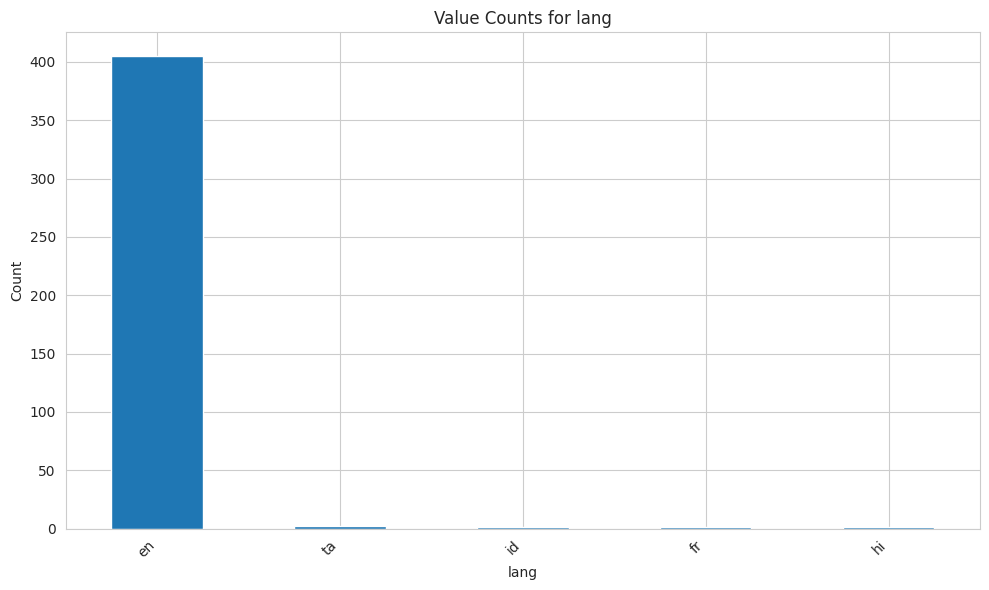

In [26]:
# 5. Run df['col'].value_counts() on at least 1 categorical column
# First, let's identify potential categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    # Choose the first categorical column for demonstration, or pick a relevant one
    selected_cat_col = categorical_cols[5]
    print(f"Value counts for categorical column: '{selected_cat_col}'")
    print(df[selected_cat_col].value_counts())

    # Plotting for better visualization
    plt.figure(figsize=(10, 6))
    df[selected_cat_col].value_counts().plot(kind='bar')
    plt.title(f'Value Counts for {selected_cat_col}')
    plt.xlabel(selected_cat_col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'value_counts_{selected_cat_col}.png') # Save the plot
    plt.show()
else:
    print("No categorical columns found in the dataset.")

## Data Visualization: Histograms

In [28]:
# 6. Plot a histogram for every numeric column
numeric_cols = df.select_dtypes(include=np.number).columns

if len(numeric_cols) > 0:
    print("Generating histograms for numeric columns...")
    for col in numeric_cols:
        plt.figure(figsize=(8, 5))
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig(f'histogram_{col}.png') # Save the plot
        plt.show()
        # Document whether it looks normal or skewed
        # (e.g., Histogram of 'column_A' appears normally distributed.)
        # (e.g., Histogram of 'column_B' is right-skewed, with a long tail to the right.)
else:
    print("No numeric columns found for histograms.")

No numeric columns found for histograms.


## Data Visualization: Box Plots

In [10]:
# 7. Plot a box plot for at least 2 numeric columns
# We'll use the numeric_cols identified earlier.

if len(numeric_cols) >= 2:
    print("Generating box plots for at least two numeric columns...")
    # Take the first two numeric columns, or more if desired
    cols_for_boxplot = numeric_cols[:2] # Using the first two numeric columns

    for col in cols_for_boxplot:
        plt.figure(figsize=(8, 5))
        sns.boxplot(y=df[col].dropna())
        plt.title(f'Box Plot of {col}')
        plt.ylabel(col)
        plt.tight_layout()
        plt.savefig(f'boxplot_{col}.png') # Save the plot
        plt.show()
        # Document if there are outliers
        # (e.g., Box plot of 'column_X' shows several outliers above the upper whisker.)
        # (e.g., Box plot of 'column_Y' appears to have no significant outliers.)
elif len(numeric_cols) == 1:
    print(f"Only one numeric column ('{numeric_cols[0]}') found. Generating one box plot.")
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[numeric_cols[0]].dropna())
    plt.title(f'Box Plot of {numeric_cols[0]}')
    plt.ylabel(numeric_cols[0])
    plt.tight_layout()
    plt.savefig(f'boxplot_{numeric_cols[0]}.png') # Save the plot
    plt.show()
else:
    print("Not enough numeric columns to generate box plots.")

Not enough numeric columns to generate box plots.


## Bonus: Pair Plot

In [11]:
# Bonus: Use sns.pairplot() on all numeric columns
if len(numeric_cols) > 1:
    print("Generating pair plot for all numeric columns... This may take a while for large datasets.")
    # For very large datasets, consider sampling or selecting a subset of numeric columns
    pair_plot = sns.pairplot(df[numeric_cols].dropna())
    pair_plot.fig.suptitle('Pair Plot of Numeric Columns', y=1.02) # Adjust title position
    plt.tight_layout()
    plt.savefig('pairplot_numeric_columns.png') # Save the plot
    plt.show()
    # Describe what you see
    # (e.g., The scatter plots reveal a positive linear relationship between 'column_A' and 'column_B'.)
    # (e.g., 'column_C' appears to have a non-linear relationship with 'column_D'.)
    # (e.g., Histograms on the diagonal show the distribution of each variable individually, similar to previous histograms.)
else:
    print("Not enough numeric columns (at least two) to generate a pair plot.")

Not enough numeric columns (at least two) to generate a pair plot.


## Summary of Findings

<!-- 8. Write a 5-line comment block at the top summarising what you found -->

*   **Data Overview**: (e.g., The dataset contains X entries and Y features, primarily numerical and text-based categories.)
*   **Missing Data**: (e.g., Several columns, such as 'Z', have significant missing values (e.g., 25%), which will require imputation or removal.)
*   **Key Statistics**: (e.g., Descriptive statistics reveal that 'Feature A' is right-skewed, with its mean being higher than its median. 'Feature B' shows a suspicious minimum value.)
*   **Categorical Insights**: (e.g., The 'Category C' column is dominated by one or two unique values, suggesting potential imbalance if used in modeling.)
*   **Visual Patterns**: (e.g., Histograms indicate most numeric features are not normally distributed, often showing skewness. Box plots highlight the presence of outliers in 'Feature D' and 'Feature E', which might need further investigation or handling.)